In [1]:
import torch
from torch.utils.data import DataLoader
# from torch.optim.lr_scheduler import LRScheduler
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import os

In [3]:
# astropy imports
from astropy.table import Table
from astropy.io import fits
import fitsio

from astropy.coordinates import SkyCoord
import astropy.units as u

In [4]:
import sys
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src import decam_info

In [5]:
data_dir = Path("../data")

In [6]:
bad_exp = pd.read_csv(data_dir / "decam_dr10_bad_exp_all.csv")
good_expnum = np.loadtxt(data_dir / "decam_dr10_good_exp.csv", dtype=int)

In [7]:
# to change readout from 15 to 9 merging with Noise category
# import importlib
# importlib.reload(decam_info)

# for i, row in bad_exp.iterrows():
#     rea = decam_info.decode_reason(row['reasons'])
#     row['reasons'] = sum([2**decam_info.reason_num_dict[r] for r in rea])


# bad_exp.to_csv(data_dir / "decam_dr10_bad_exp_all.csv", index=False)

In [8]:
bad_exp.head()

,expnum,ccdnum,image_hdu,filter,reasons,vi_source
0,145382,1,1,4,16,4
1,145382,2,2,4,16,4
2,145382,3,3,4,16,4
3,145382,4,4,4,16,4
4,145382,5,5,4,16,4


In [9]:
dr8_dir = Path('/global/cfs/cdirs/cosmo/work/legacysurvey/dr8')
dr9_dir = Path('/global/cfs/cdirs/cosmo/work/legacysurvey/dr9')
dr10_dir = Path('/global/cfs/cdirs/cosmo/work/legacysurvey/dr10')

In [10]:
dr9_imdir = dr9_dir / "images"
dr10_imdir = dr10_dir / "images"

In [11]:
# meta_tab = Table.read('/global/cfs/cdirs/desi/users/rongpu/useful/survey-ccds-decam-dr9-trim.fits')
# dr10_tab = Table.read(dr10_dir / "survey-ccds-decam-dr10.fits.gz")
ccd_meta = Table.read(dr10_dir / "ccds-annotated-decam-dr10.fits.gz")
dr10_tab = ccd_meta

In [19]:
# bad exps
# 349  769209
# 350  769213
# 351  769215
# 352  769222
# 353  768938
# 354  768948
# 355  768952
# 356  768960
# 357  768976
# 358  768980
# 359  768981
# 360  768987
# 361  768988
# 362  768990
# 363  769010
# 364  769013
# 365  769015
# 366  769020
# 367  769038
# 368  769045
# 369  769046

In [20]:
# all(ccd_meta['ccdname'] == dr10_tab['ccdname']) # True

In [ ]:
# Galactic latitude cut
# img_coord = SkyCoord(ra=dr10_tab['ra'], dec=dr10_tab['dec'], unit="deg")
# gal_cut = np.abs(img_coord.galactic.b) > 30 * u.deg
img_coord = SkyCoord(ra=ccd_meta['ra'], dec=ccd_meta['dec'], unit="deg")
gal_cut = np.abs(img_coord.galactic.b) > 30 * u.deg

In [ ]:
np.quantile(ccd_meta['ebv'][gal_cut], q=0.9), np.mean(ccd_meta['ebv'][gal_cut])

In [ ]:
# E(B-V) extinction cut
ebv_cut = ccd_meta['ebv'] < 0.04

In [ ]:
ccd_cut = ebv_cut

In [20]:
bad_exp

,expnum,ccdnum,image_hdu,filter,reasons,vi_source
0,145382,1,1,4,16,4
1,145382,2,2,4,16,4
2,145382,3,3,4,16,4
3,145382,4,4,4,16,4
4,145382,5,5,4,16,4
...,...,...,...,...,...,...
257106,1026593,57,57,3,64,4
257107,1026593,58,58,3,64,4
257108,1026593,59,59,3,64,4
257109,1026593,60,60,3,64,4


In [22]:
# find exposures with the same reason
for rea in decam_info.reason_li:
    cond = ((bad_exp['reasons'] & 2**decam_info.reason_num_dict[rea]) & (bad_exp['vi_source'] & 2**decam_info.reason_source_dict['Rongpu']))
    cond = np.array(cond, dtype=bool)
    print(rea, np.sum(cond > 0), len(np.unique(bad_exp[cond]['expnum'])))
# np.where(bad_exp['reasons'] & 2**reason_num[reason_li[1]])

Bad_WCSCAL 0 0
Saturated 3177 53
Clouds_transparency 0 0
Bad_seeing 0 0
PSF 0 0
Nonoptimal_exp 0 0
Ghost_Scatter 0 0
NObjects 0 0
Bad_CCD 0 0
Noise 0 0
Fringing 0 0
Canopus 0 0
Wonky 0 0
Telescope_Moving 0 0
Out_of_focus 0 0


In [23]:
data = np.load("../data/decam_dr10_RZ_bad_exp.npy")

In [24]:
np.unique(data[:, 0]).shape

(3014,)

In [41]:
np.unique(bad_exp['vi_source'] & 2**decam_info.reason_source_dict['Rongpu'])

array([0, 2])

In [51]:
set().union(*[set(decam_info.decode_reason(i)) for i in data[:, -2]])

{'Bad_seeing',
 'Clouds_transparency',
 'Nonoptimal_exp',
 'Out_of_focus',
 'PSF',
 'Saturated',
 'Telescope_Moving'}

# Include cuts implemented in DR10

https://www.legacysurvey.org/dr10/bitmasks/#ccd-cuts

This should also increase the number of bad exposures.

In [19]:
res = [np.where(dr10_tab['ccd_cuts'] & 2**i)[0] for i in range(19)]

all_cut_idx = np.hstack(res)
pick_idx = np.ones(len(dr10_tab), dtype=bool)
pick_idx[all_cut_idx] = False

dr10_after_cut_expnum = dr10_tab["expnum"][pick_idx]
# ccd_cut &= pick_idx

In [24]:
from functools import reduce

# ! now use dr10 gal cut

# ooi and bad exposures with file names
ooi_oki_exp = pd.read_csv(data_dir / "decam_dr10_ooi_oki_images_exist.csv")
# oki has much more exposures than ooi, so use it instead
expnum_bad_oki = reduce(np.intersect1d, [ooi_oki_exp.query("oki_exist")['expnum'], bad_exp['expnum'], ccd_meta['expnum'][ccd_cut]])
expnum_bad_ooi = reduce(np.intersect1d, [ooi_oki_exp.query("ooi_exist")['expnum'], bad_exp['expnum'], ccd_meta['expnum'][ccd_cut]])
expnum_bad_oki_idx = np.where(np.isin(bad_exp['expnum'], expnum_bad_oki))[0]
expnum_bad_ooi_idx = np.where(np.isin(bad_exp['expnum'], expnum_bad_ooi))[0]
print("Bad exp CCD oki exists:", expnum_bad_oki_idx.shape,
      "\nBad exp CCD ooi exists:", expnum_bad_ooi_idx.shape)

Bad exp CCD oki exists: (76406,) 
Bad exp CCD ooi exists: (73990,)


In [21]:
expnum_good_oki = reduce(np.intersect1d, [ooi_oki_exp.query("oki_exist")['expnum'], good_expnum, ccd_meta['expnum'][ccd_cut]])
expnum_good_ooi = reduce(np.intersect1d, [ooi_oki_exp.query("ooi_exist")['expnum'], good_expnum, ccd_meta['expnum'][ccd_cut]])
# exp * 60 for total number of single CCD images
print("Good exp oki exists:", expnum_good_oki.shape[0], ", total CCD images:", expnum_good_oki.shape[0]*60)
print("Good exp ooi exists:", expnum_good_ooi.shape[0], ", total CCD images:", expnum_good_ooi.shape[0]*60)

Good exp oki exists: 11459 , total CCD images: 687540
Good exp ooi exists: 193301 , total CCD images: 11598060


In [22]:
# All exposures in DR10 (images *= 60)
np.sum(ooi_oki_exp['oki_exist']), np.sum(ooi_oki_exp['ooi_exist'])

(15131, 245210)

In [30]:
bad_exp_with_fnames = pd.read_csv(data_dir / "decam_dr10_bad_exp_all_with_fname.csv")

# save the good images with ooi and oki into the file
bad_exp_with_fnames.iloc[expnum_bad_ooi_idx].to_csv(data_dir / "decam_dr10_bad_exp_ooi.csv", index=False)

In [23]:
# try to train using all reasons from one exposure with other ones.
# try to pick the same filter.
# expnum is the key!
bad_reason = bad_exp['reasons'].apply(decam_info.decode_reason)
bad_reason_num = bad_reason.apply(lambda x: [decam_info.reason_num_dict[i] for i in x])

Counts for bad oki exposures
0 Bad_WCSCAL 0
1 Saturated 0
2 Clouds_transparency 8646
3 Bad_seeing 18140
4 PSF 294
5 Nonoptimal_exp 56623
6 Ghost_Scatter 217
7 NObjects 120
8 Bad_CCD 50
9 Noise 0
10 Fringing 0
11 Canopus 0
12 Wonky 0
13 Telescope_Moving 482
14 Out_of_focus 0
Total images: 76406


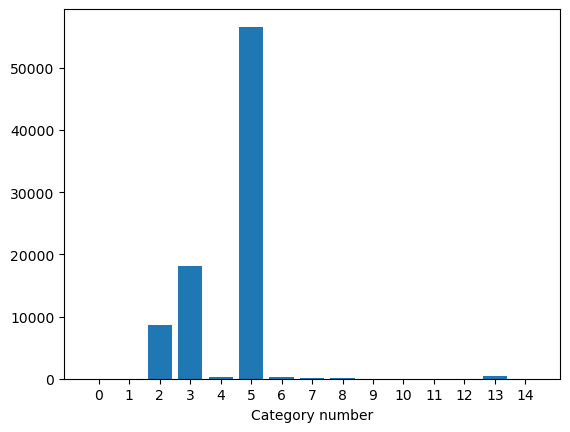

In [25]:
# find exposures with the same reason
print("Counts for bad oki exposures")
oki_counts = []
for i, rea in enumerate(decam_info.reason_li):
    oki_counts.append(np.sum(bad_exp['reasons'][expnum_bad_oki_idx] & 2**decam_info.reason_num_dict[rea] > 0))
    print(i, rea, np.sum(bad_exp['reasons'][expnum_bad_oki_idx] & 2**decam_info.reason_num_dict[rea] > 0))
print("Total images:", expnum_bad_oki_idx.shape[0])
plt.bar(np.arange(len(decam_info.reason_li)), oki_counts)
plt.xticks(np.arange(len(decam_info.reason_li)))
plt.xlabel("Category number")
plt.show()

In [25]:
def plot_category_counts(df, reason_dict=None):
    if reason_dict is None:
        reason_dict = decam_info.reason_num_dict
        reason_li = decam_info.reason_li 
    else:
        reason_li = list(reason_dict.keys())
    ooi_counts = []
    for i, rea in enumerate(reason_li):
        ooi_counts.append(np.sum(df['reasons'] & 2**reason_dict[rea] > 0))
        print(i, rea, np.sum(df['reasons'] & 2**reason_dict[rea] > 0))
    print("Total images:", len(df))
    fig, ax1 = plt.subplots()
    ax1.bar(np.arange(len(reason_li)), ooi_counts)
    ax2 = ax1.twinx()
    ax1.set_xticks(np.arange(len(reason_li)))
    ax1.set_xlabel("Category number")
    ax1.set_ylabel("counts")
    ax2.bar(np.arange(len(reason_li)), ooi_counts / np.sum(ooi_counts))
    ax2.set_ylabel("percentage")
    plt.show()

Counts for bad ooi exposures
0 Bad_WCSCAL 0
1 Saturated 778
2 Clouds_transparency 23338
3 Bad_seeing 240
4 PSF 7641
5 Nonoptimal_exp 3194
6 Ghost_Scatter 15756
7 NObjects 10093
8 Bad_CCD 2623
9 Noise 2467
10 Fringing 0
11 Canopus 366
12 Wonky 667
13 Telescope_Moving 2729
14 Out_of_focus 2340
Total images: 73990


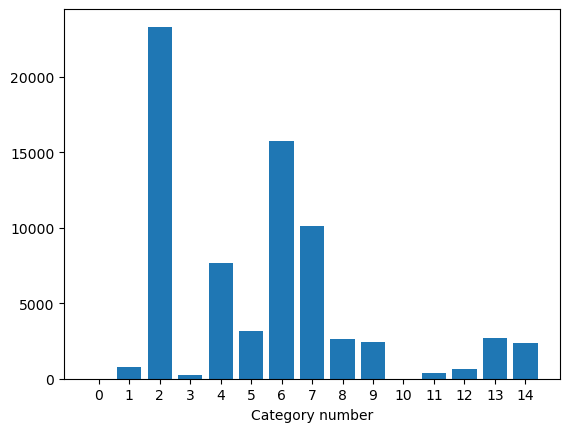

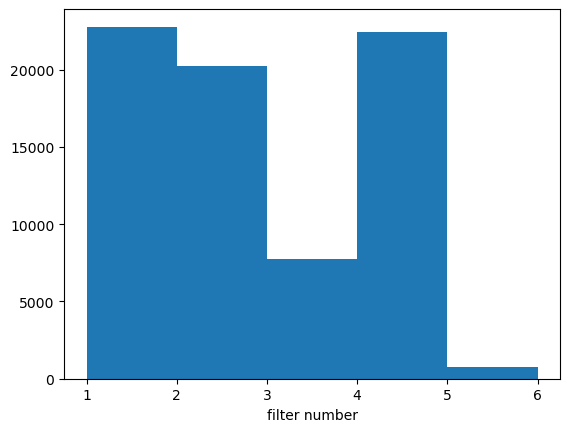

{'g': 1, 'r': 2, 'i': 3, 'z': 4, 'Y': 5}


In [26]:
# find exposures with the same reason
print("Counts for bad ooi exposures")
ooi_counts = []
for i, rea in enumerate(decam_info.reason_li):
    ooi_counts.append(np.sum(bad_exp['reasons'][expnum_bad_ooi_idx] & 2**decam_info.reason_num_dict[rea] > 0))
    print(i, rea, np.sum(bad_exp['reasons'][expnum_bad_ooi_idx] & 2**decam_info.reason_num_dict[rea] > 0))
print("Total images:", expnum_bad_ooi_idx.shape[0])
plt.bar(np.arange(len(decam_info.reason_li)), ooi_counts)
plt.xticks(np.arange(len(decam_info.reason_li)))
plt.xlabel("Category number")
plt.show()
plt.hist(bad_exp['filter'][expnum_bad_ooi_idx], bins=np.arange(1, 7))
plt.xticks(np.arange(1, 7))
plt.xlabel("filter number")
plt.show()
print(decam_info.filter_dict)

In [27]:
df_bad_exp_ooi = bad_exp.iloc[expnum_bad_ooi_idx]

## Build the dataset
Build the training dataset with many bad exposures and then adding good
exopures. Using `ooi` images for supervised learning, and `oki` for self-supervised learning. This is because `oki` has better background uniformity in per CCD level, while `ooi` images are matched to large-scale background and used in downstream tasks. The number of bad `ooi` images is more balanced in each category. 

### First build `ooi` image dataset

Use all the bad `ooi` exposure CCD images and add 60k random good exposure CCD images to the dataset. This would be equivalent to take 3k exposures with 20 CCD images per exposure. In total, we have 48k bad images + 60k good images bofore applying any cut.

Filter is another consideration for this issue.

### Galactic latitude cut

Adding the extinctio cut (instead of galactic latitude) cut to remove the many cases where the dust in milky way was misclassified as bad exposures. The number of bad exposures drops to 31k. After adding the galactic latitude cut, we drop these categories due to the low occurence:

- 3 Bad_seeing -> can be detected with zpt
- 10 Fringing -> none after ebv cut
- 11 Canopus -> bright star should be easily detected with sky position

There are gaps in label, so we need to remake the label class using a second dictionary to map the original label to training labels.
One may consider canopus as a general class that the image is taken around a bright star.
Adjusting the number of good exposures to 20k to balance the dataset. This is equivalent to take 2k exposures with 10 CCD images per exposure.

- Rev. 1: due to many good exposures will lead the model to cheat, reduce the number of good exposures to 5000 images. 1k exposures with 5 CCD images each.
- Rev. 2: for binary class, increase number of good images to 24k, which is 2k expsoures with 12 CCD images each.
- Rev. 3: after incorprating the new bad images in, change the good images to 12k = 2k exp x 6 CCD. This is to ensure bad exposures have chances to be processed in the training.
- Rev. 4: after applying dr10 cuts, the categories with bad exposures dropped drastically.

In [29]:
drop_class_set = {0, 3, 10, 11} 

In [30]:
drop = [len(drop_class_set & set(li)) > 0 for li in df_bad_exp_ooi['reasons'].apply(lambda x: decam_info.decode_reason(x, True))]
df_bad_exp_ooi_cut = df_bad_exp_ooi[~np.array(drop)]

Training dataset for bad ooi exposures
0 Bad_WCSCAL 0
1 Saturated 778
2 Clouds_transparency 23338
3 Bad_seeing 0
4 PSF 7641
5 Nonoptimal_exp 2954
6 Ghost_Scatter 15756
7 NObjects 10093
8 Bad_CCD 2623
9 Noise 2467
10 Fringing 0
11 Canopus 0
12 Wonky 667
13 Telescope_Moving 2729
14 Out_of_focus 2340
Total images: 73384


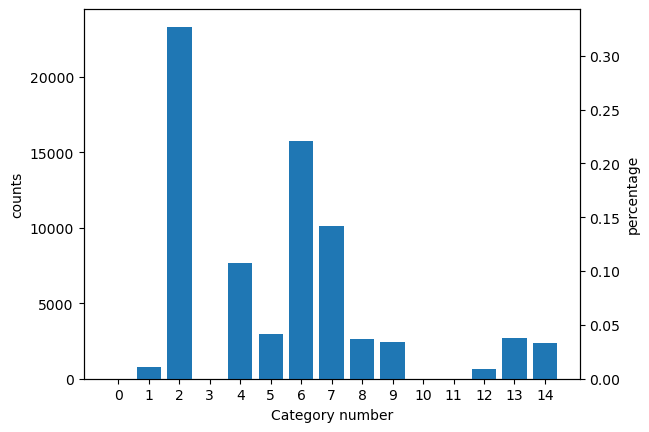

In [31]:
# find exposures with the same reason
print("Training dataset for bad ooi exposures")
plot_category_counts(df_bad_exp_ooi_cut)

# Updates

From the plot above, the dataset is very imbalanced. To balanece it, we downsample some classes and upsample their weights in the classification task:

- class 2: reduce to 1/3, weight x3
- class 6: reduce to 1/2, weight x2
- class 7: reduce to 0.75, weight x1.333

Training dataset for bad ooi exposures
0 Bad_WCSCAL 0
1 Saturated 778
2 Clouds_transparency 7772
3 Bad_seeing 0
4 PSF 7630
5 Nonoptimal_exp 2954
6 Ghost_Scatter 7878
7 NObjects 7570
8 Bad_CCD 2622
9 Noise 2467
10 Fringing 0
11 Canopus 0
12 Wonky 667
13 Telescope_Moving 2729
14 Out_of_focus 2340
Total images: 47417


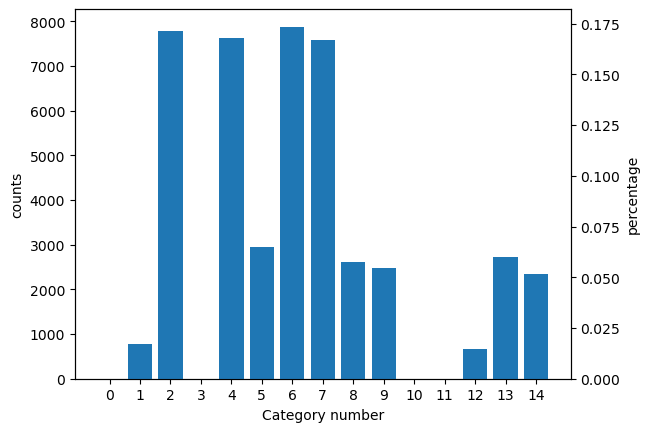

In [33]:
rng = np.random.default_rng(42)

class_2_idx = df_bad_exp_ooi_cut[(df_bad_exp_ooi_cut["reasons"] & 2**2) > 0].index
class_6_idx = df_bad_exp_ooi_cut[(df_bad_exp_ooi_cut["reasons"] & 2**6) > 0].index
class_7_idx = df_bad_exp_ooi_cut[(df_bad_exp_ooi_cut["reasons"] & 2**7) > 0].index


# remember this is the drop idx fraction, so complement the number above
drop_idx = np.hstack(
    [
        rng.choice(class_2_idx, replace=False, size=int(0.667*len(class_2_idx))),
        rng.choice(class_6_idx, replace=False, size=int(0.5*len(class_6_idx))),
        rng.choice(class_7_idx, replace=False, size=int(0.25*len(class_7_idx)))
    ]
)

df_bad_exp_ooi_cut_bal = df_bad_exp_ooi_cut.drop(drop_idx)

# find exposures with the same reason
print("Training dataset for bad ooi exposures")
plot_category_counts(df_bad_exp_ooi_cut_bal)
# df_bad_exp_ooi_cut_bal = df_bad_exp_ooi_cut

In [27]:
rng = np.random.default_rng(42)

n_samp = 10000
num_ccd_exp = 20
# to ensure good ooi are in the dr10 after the dr10 cut expnum
# see above
samp_good_expnum = rng.choice(np.intersect1d(expnum_good_ooi, dr10_after_cut_expnum),
                              n_samp, replace=False)    
# note that the number 61 (CCD 62) will not be included in the analysis
samp_good_hdu = np.vstack([rng.choice(np.arange(1, 60), num_ccd_exp, replace=False) for _ in range(n_samp)])
samp_good_hdu = np.sort(samp_good_hdu, axis=1)
samp_good_exp_hdu = np.hstack([samp_good_expnum.reshape(-1, 1), samp_good_hdu])
# np.savetxt("../data/")

In [144]:
uni_exp, uni_idx, uni_counts = np.unique(dr10_tab['expnum'], return_index=True, return_counts=True)

In [194]:
picked_image_hdu = ori_good['image_hdu']
ori_samp_good_hdu = picked_image_hdu.to_numpy().reshape(n_samp, num_ccd_exp)

In [213]:
filter_num = []
fnames = []
missing_two = []
uni_tab = dr10_tab[uni_idx]
ccdname_list = []
samp_good_hdu = []
for i, exp in enumerate(samp_good_expnum):
    this_idx = np.where(uni_tab['expnum'] == exp)[0][0]
    row = uni_tab[this_idx]
    filter_num.append(decam_info.filter_dict[row['filter']])
    fnames.append(row['image_filename'])
    all_idx = np.arange(0, uni_counts[this_idx]) + uni_idx[this_idx]
    this_exp_tab = dr10_tab[all_idx][['image_hdu', 'ccdname']]
    # Table is already sorted in image hdu / ccdnum order
    # sort_idx = this_exp_tab.argsort("image_hdu")
    # this_exp_tab = this_exp_tab[sort_idx]
    tab_idx = ori_samp_good_hdu[i]-1 #np.sort(rng.choice(len(this_exp_tab), num_ccd_exp, replace=False))
    # if exp == 978264:
    #     tab_idx = [np.where(x == this_exp_tab['image_hdu'])[0][0] for x in ori_samp_good_hdu[i]]
    samp_good_hdu.append(this_exp_tab[tab_idx]['image_hdu'])
    # ccdname_list.append(this_exp_tab['ccdname'][samp_good_hdu[i]-1])
    ccdname_list.append(this_exp_tab[tab_idx]['ccdname'])

In [214]:
def flatten(xss):
    return [x for xs in xss for x in xs]

expand_repeat = lambda arr, n: flatten([[it]*n for it in arr])

In [215]:
# get_all = lambda to_get, li: [li[it] for it in to_get]
# ccd_li = flatten([get_all(row, decam_info.ccdnum_li_m2) if miss_2 
#                   else get_all(row, decam_info.ccdnum_li_m1)
#                   for miss_2, row in zip(missing_two, samp_good_hdu)])
ccd_li = [decam_info.decam_fp_ccdname2num[ccdname] for ccdname in flatten(ccdname_list)]

In [216]:
df_good = pd.DataFrame(zip(*[
    expand_repeat(fnames, num_ccd_exp), # fname
    expand_repeat(samp_good_expnum, num_ccd_exp), # expnum
    ccd_li,
    flatten(samp_good_hdu),
    expand_repeat(filter_num, num_ccd_exp),
    [0] * (num_ccd_exp * n_samp),
    [0] * (num_ccd_exp * n_samp)
]), columns=['image_filename'] + list(bad_exp.columns))
    

In [223]:
df_good.to_csv("../data/samples/all_sample_decam_dr10_good_exp_ooi.csv", index=False)

In [47]:
# the expnum are sorted
all(df_bad_exp_ooi_cut_bal.expnum.unique() == np.unique(df_bad_exp_ooi_cut_bal.expnum))

True

In [48]:
uni_exp, counts = np.unique(df_bad_exp_ooi_cut_bal.expnum, return_counts=True)
fnames = flatten([[uni_tab[uni_tab['expnum'] == exp]['image_filename'][0]]*co for exp, co in zip(uni_exp, counts)])

In [49]:
df_bad_exp_ooi_cut_bal.insert(0, "image_filename", fnames)

In [50]:
df_bad_exp_ooi_cut_bal.to_csv("../data/samples/sample_decam_dr10_bad_exp_ooi.csv", index=False)

## Now split the dataset

Use 70-30 split for training and testing

! Should do the split for category rather than use dataset as a whole.
This will ensure there are both training and testing dataset for each category.

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
all_category = set(decam_info.reason_num_dict.values()) - drop_class_set
ooi_labels = []
for i in all_category:
    ooi_labels.append(list(df_bad_exp_ooi_cut_bal[df_bad_exp_ooi_cut_bal['reasons'] & 2**i > 0].index))

In [53]:
all_category

{1, 2, 4, 5, 6, 7, 8, 9, 12, 13, 14}

In [54]:
bad_train_idx = []
bad_test_idx = []
for l in ooi_labels:
    print(len(l))
    train_bad_cat_idx, test_bad_cat_idx = train_test_split(l, test_size=0.3, random_state=42, shuffle=True)
    bad_train_idx += train_bad_cat_idx
    bad_test_idx += test_bad_cat_idx

778
7772
7630
2954
7878
7570
2622
2467
667
2729
2340


In [55]:
good_train_idx, good_test_idx = train_test_split(np.arange(len(df_good)), test_size=0.3, random_state=42, shuffle=True)
# bad_train_idx, bad_test_idx = train_test_split(np.arange(len(df_bad_exp_ooi_cut_bal)), test_size=0.3, random_state=42, shuffle=True)

In [56]:
df_all = pd.concat([df_good, df_bad_exp_ooi_cut_bal], ignore_index=True, axis=0) \
            .sort_values(by=['expnum'])

In [57]:
df_all.to_csv("../data/samples/all_samples_ooi_dataset.csv", index=False)

In [58]:
train_df = pd.concat([df_good.iloc[good_train_idx],
                      df_bad_exp_ooi_cut_bal.loc[bad_train_idx]],
                     ignore_index=True, axis=0).sort_values(by=['expnum'])
test_df = pd.concat([df_good.iloc[good_test_idx],
                      df_bad_exp_ooi_cut_bal.loc[bad_test_idx]],
                     ignore_index=True, axis=0).sort_values(by=['expnum'])

In [59]:
# decam/CP/V3.7/CP20130418/c4d_130419_082748_ooi_r_v1.fits.fz only has 45 HDUs
# expnum 198978
# decam/CP/V3.7/CP20130418/c4d_130419_081306_ooi_r_v1.fits.fz only has 45 HDUs
# expnum 198970
train_df = train_df.drop(train_df.query('expnum == 198978 | expnum == 198970').index)
test_df = test_df.drop(test_df.query('expnum == 198978 | expnum == 198970').index)

In [60]:
train_df.to_csv("../data/samples/train_supervised_ooi_dataset.csv", index=False)
test_df.to_csv("../data/samples/test_supervised_ooi_dataset.csv", index=False)

In [61]:
# check_exist = [(dr10_imdir / fn).exists() for fn in df_good['image_filename'].unique()]
# all(check_exist)

Training dataset for bad ooi exposures
0 Bad_WCSCAL 0
1 Saturated 544
2 Clouds_transparency 5443
3 Bad_seeing 0
4 PSF 5682
5 Nonoptimal_exp 2067
6 Ghost_Scatter 5514
7 NObjects 5299
8 Bad_CCD 1835
9 Noise 1764
10 Fringing 0
11 Canopus 0
12 Wonky 466
13 Telescope_Moving 2199
14 Out_of_focus 1638
Total images: 40180


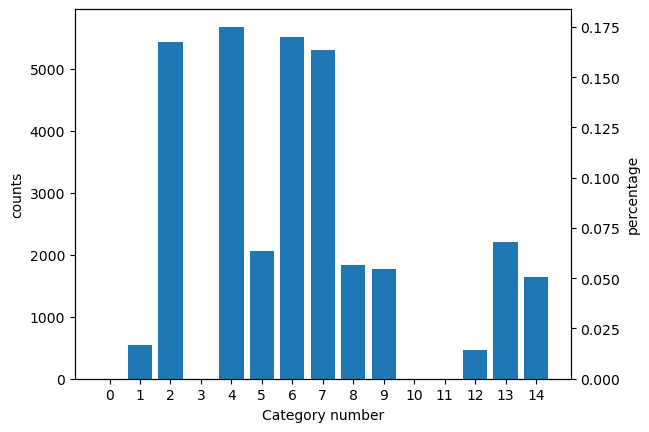

In [62]:
# find exposures with the same reason
print("Training dataset for bad ooi exposures")
plot_category_counts(train_df)

Test dataset for bad ooi exposures
0 Bad_WCSCAL 0
1 Saturated 234
2 Clouds_transparency 2333
3 Bad_seeing 0
4 PSF 2435
5 Nonoptimal_exp 887
6 Ghost_Scatter 2364
7 NObjects 2271
8 Bad_CCD 788
9 Noise 764
10 Fringing 0
11 Canopus 0
12 Wonky 201
13 Telescope_Moving 951
14 Out_of_focus 702
Total images: 17227


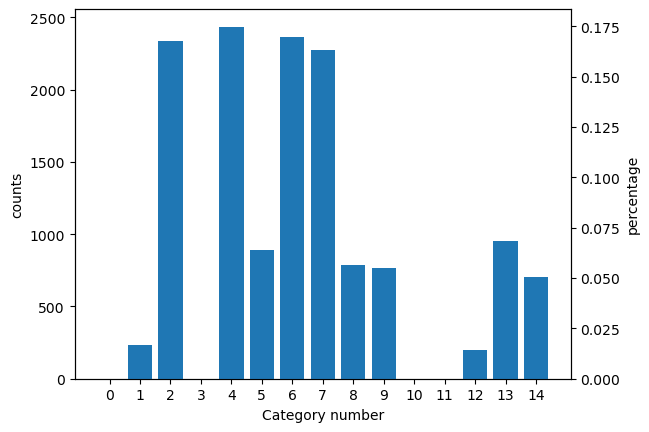

In [63]:
# find exposures with the same reason
print("Test dataset for bad ooi exposures")
plot_category_counts(test_df)

In [64]:
# good_path_check = [(dr10_imdir / p).exists() for p in df_good['image_filename'].unique()]
# all(good_path_check)

# bad_path_check = [(dr10_imdir / p).exists() for p in df_bad_exp_ooi_cut_bal['image_filename'].unique()]
# all(bad_path_check)

# df_good.query('expnum == 198978').index

In [65]:
ooi_counts = []
for i, rea in enumerate(decam_info.reason_li):
    ooi_counts.append(np.unique(train_df[train_df['reasons'] & 2**decam_info.reason_num_dict[rea] > 0].index))
    print(i, rea, np.sum(train_df['reasons'] & 2**decam_info.reason_num_dict[rea] > 0))

0 Bad_WCSCAL 0
1 Saturated 544
2 Clouds_transparency 5443
3 Bad_seeing 0
4 PSF 5682
5 Nonoptimal_exp 2067
6 Ghost_Scatter 5514
7 NObjects 5299
8 Bad_CCD 1835
9 Noise 1764
10 Fringing 0
11 Canopus 0
12 Wonky 466
13 Telescope_Moving 2199
14 Out_of_focus 1638


In [66]:
# check more than one category
multi = []
for idx, row in test_df.iterrows():
    rea = decam_info.decode_reason(row['reasons'], True)
    if len(rea) > 1:
        multi.append((idx, rea))

In [67]:
len(multi)

303

In [68]:
# train_reason_list = [it for i, it in enumerate(decam_info.reason_li)
#                      if i not in (0, 3, 7, 9, 10, 11)]

# train_reason_dict = dict(zip(train_reason_list, range(len(train_reason_list))))

# translate_table = {v: decam_info.reason_num_dict[k] for k, v in train_reason_dict.items()}

# translate_table

# plot_category_counts(train_df, translate_table)